In [23]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

df = pd.read_csv("test_predictions_with_truth.csv")
y_true = df["true_glucose"]
y_pred = df["predicted_glucose"]

In [ ]:
len(y_true)//5

182

In [ ]:
mae = mean_absolute_error(y_true, y_pred)
print("MAE:", mae)

MAE: 19.110258790570175


In [26]:
rmse = mean_squared_error(y_true, y_pred)
print("RMSE:", rmse)

RMSE: 670.2097267310287


In [27]:
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
print("MAPE:", mape)

MAPE: 12.370756726429933


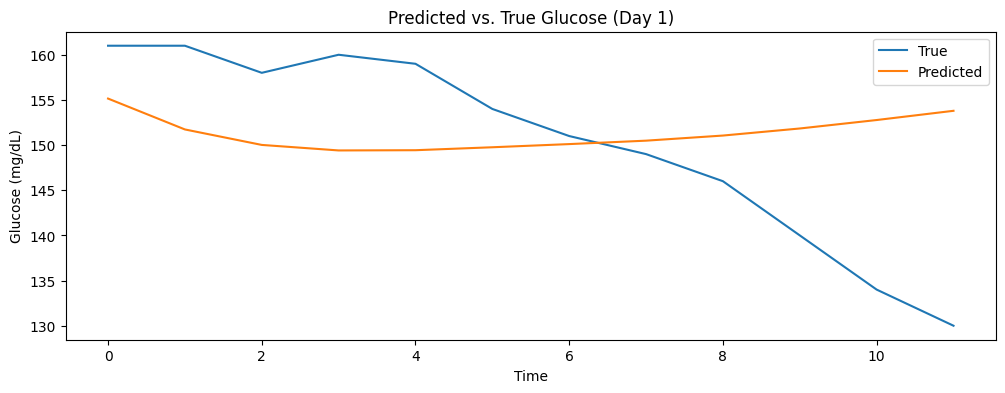

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(y_true[:12], label="True")
plt.plot(y_pred[:12], label="Predicted")
plt.legend()
plt.title("Predicted vs. True Glucose (Day 1)")
plt.xlabel("Time")
plt.ylabel("Glucose (mg/dL)")
plt.show()


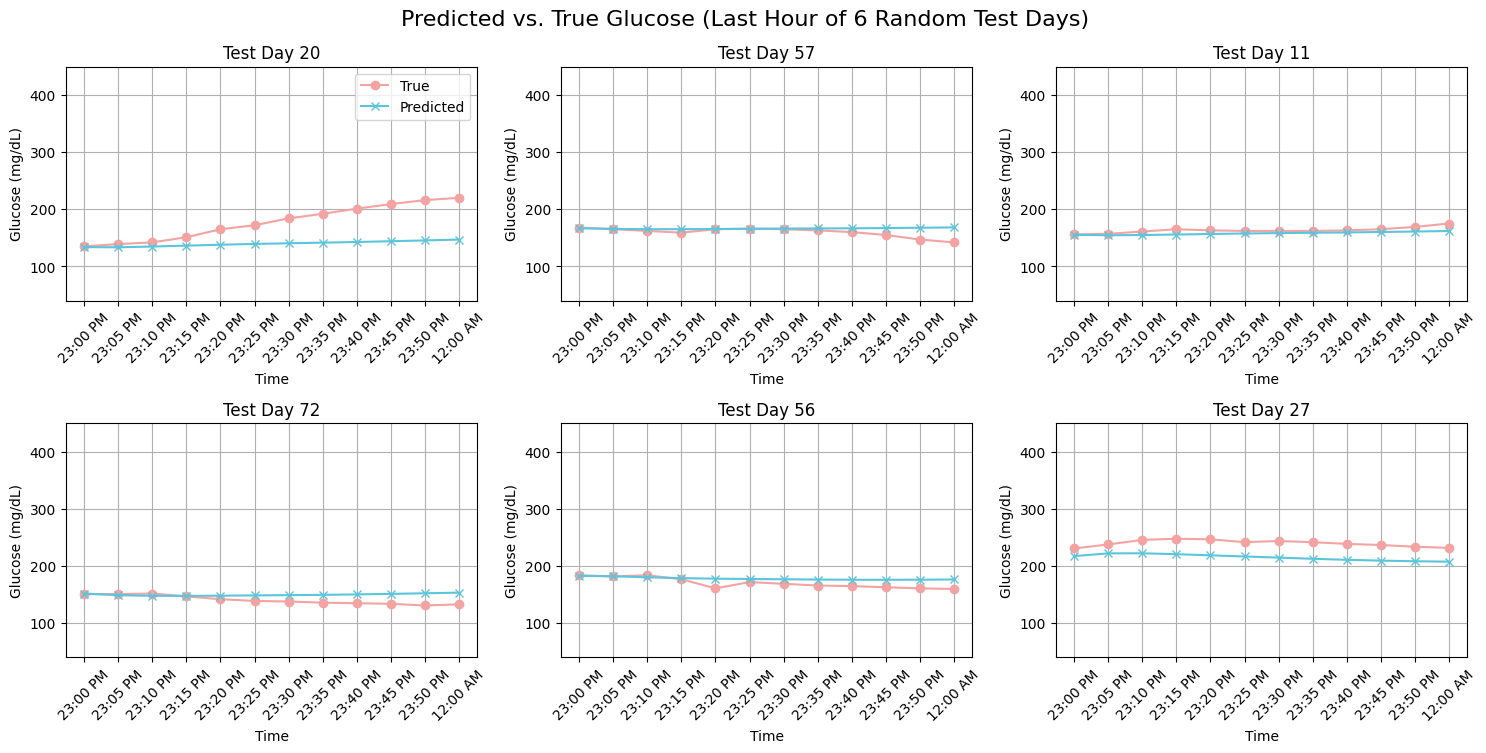

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Sanity check: make sure y_pred and y_true are NumPy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Number of predictions per day (you said 12)
preds_per_day = 12
num_days = len(y_true) // preds_per_day

# Define time-of-day labels for the last hour (every 5 mins from 11:00 PM to 12:00 AM)
time_labels = [f"{h:02d}:{m:02d} {'PM' if h < 24 else 'AM'}" 
               for h, m in [(23, i * 5) for i in range(12)]]
time_labels[-1] = "12:00 AM"

# Select 7 random days to visualize
np.random.seed(1)  # for reproducibility
day_indices = np.random.choice(num_days, size=6, replace=False)

# Plot
plt.figure(figsize=(15, 10))
for i, day_idx in enumerate(day_indices):
    start = day_idx * preds_per_day
    end = start + preds_per_day

    plt.subplot(3, 3, i + 1)
    plt.plot(y_true[start:end], label="True", color="#F4A3A3", marker="o")
    plt.plot(y_pred[start:end], label="Predicted", color="#5BC5DB", marker="x")
    plt.title(f"Test Day {day_idx + 1}")
    plt.xlabel("Time")
    plt.ylabel("Glucose (mg/dL)")
    plt.xticks(ticks=np.arange(preds_per_day), labels=time_labels, rotation=45)
    plt.ylim(40, 450)
    plt.grid(True)
    if i == 0:
        plt.legend()

plt.tight_layout()
plt.suptitle("Predicted vs. True Glucose (Last Hour of 6 Random Test Days)", fontsize=16, y=1.02)
plt.show()


## Methods Visuzalizations

In [30]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


/var/folders/pk/qdmff8mj1cd05f2h6z7fld0r0000gn/T/ipykernel_72467/2599922052.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='model', y='val_loss', palette = ["#F4A3A3", "#AEE7F2"])


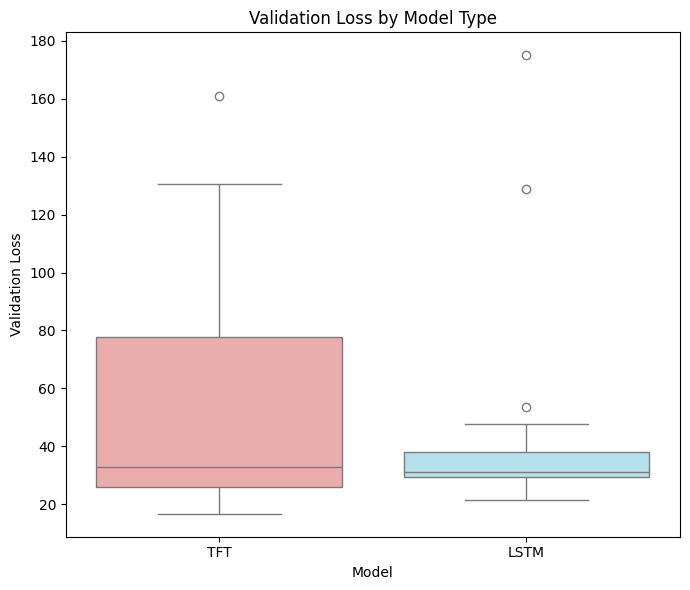

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load CSV ---
# Replace with your actual file path
lstm_df = pd.read_csv("/Users/laurenbeede/Downloads/lstm_sweep.csv")
tft_df = pd.read_csv("/Users/laurenbeede/Downloads/tft_sweep.csv")

# --- Add model column ---
tft_df['model'] = 'TFT'
lstm_df['model'] = 'LSTM'

# --- Standardize column names (adjust if needed) ---
# For example, your val_loss might be in 'summary.val_loss' or similar
val_loss_col = "val_loss"
if 'summary.val_loss' in tft_df.columns:
    val_loss_col = "summary.val_loss"
    tft_df.rename(columns={val_loss_col: "val_loss"}, inplace=True)
    lstm_df.rename(columns={val_loss_col: "val_loss"}, inplace=True)

# --- Combine both sweeps ---
df = pd.concat([tft_df, lstm_df], ignore_index=True)

# --- Filter only finished runs if necessary ---
if 'state' in df.columns:
    df = df[df['state'] == 'finished']

# --- Plot ---
plt.figure(figsize=(7, 6))
sns.boxplot(data=df, x='model', y='val_loss', palette = ["#F4A3A3", "#AEE7F2"])
plt.title("Validation Loss by Model Type")
plt.xlabel("Model")
plt.ylabel("Validation Loss")
plt.tight_layout()
plt.show()
